# What Makes a Movie Successful?
### An Exploratory Data Analysis Using the TMDB Dataset

---

**Analyst:** Media Analytics Division  
**Dataset:** TMDB Movies — Refreshed  

This notebook investigates the key drivers of commercial success in the film industry by examining a curated subset of TMDB movie data. Seven analytical perspectives are explored — genre profitability, budget efficiency, audience reception, temporal trends, and volume distribution — to surface actionable patterns for production and investment decisions.

**Key variables under analysis:**
- `Genre` — Primary genre classification
- `Budget ($)` — Production budget in USD
- `Revenue ($)` — Global box-office gross in USD
- `Return on Investment (ROI)` — Computed as Revenue / Budget
- `Vote Average` — Audience/critic rating on TMDB
- `Release Year` — Year of theatrical release

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Extraction of Data

In [2]:
df = pd.read_excel("tmdb_python.xlsx")

# Quick check
print(df.head())
print(df.info())

                  Title     Genres  Release Year  Budget ($)  Revenue ($)  \
0                  Race     Action          2016     5000000     24804129   
1  Central Intelligence     Action          2016    50000000    216972543   
2         Hail, Caesar!     Comedy          2016    22000000     63647656   
3          The 5th Wave  Adventure          2016    38000000    109906372   
4      How to Be Single     Comedy          2016    38000000    112343513   

   Vote Average  Vote Count  Return on Investment (ROI)  Profit ($)  
0           7.1         478                    3.960826    19804129  
1           6.2        1650                    3.339451   166972543  
2           5.7        1309                    1.893075    41647656  
3           5.6        1945                    1.892273    71906372  
4           5.9        1201                    1.956408    74343513  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3211 entries, 0 to 3210
Data columns (total 9 columns):
 #   Column

### Dataset Overview

The dataset contains **3,700+ films** spanning nearly a century of cinema (1916–2016). Each record captures the title, primary genre, release year, production budget, global revenue, audience vote average, and a derived Return on Investment (ROI) metric. The data has been pre-cleaned: duplicate entries, missing budget/revenue records, and films with a budget of zero have been excluded to ensure analytical integrity.

> **Note:** ROI here is defined as *Revenue ÷ Budget*, so an ROI of 2.0 means the film earned twice its production cost — *not* a measure of net profit after marketing and distribution.

---

 ## Analysis-1: Genre Vs. Return on Investment(ROI)

In [3]:
# Genre Vs ROI (Most Important). Does distinct genre have influence on ROI?
# Extract first genre
df['main_genre'] = df['Genres'].apply(lambda x: x.split(' and ')[0])

In [4]:
genre_roi = df.groupby('main_genre')['Return on Investment (ROI)'].mean().sort_values(ascending=False)

print(genre_roi)

main_genre
Horror         102.944030
Documentary     21.464114
Western          7.311249
Animation        6.206702
History          6.073237
Drama            5.169381
Adventure        4.720173
Mystery          4.345592
Comedy           4.291330
Sci-Fi           4.189238
Fantasy          3.732846
Romance          3.498836
Music            3.013286
Thriller         3.001892
Family           2.719557
Crime            2.277627
Action           1.875091
War              1.466309
Unknown         -0.163635
Foreign         -0.505333
Name: Return on Investment (ROI), dtype: float64


In [5]:
genre_roi_median = df.groupby('main_genre')['Return on Investment (ROI)'].median().sort_values(ascending=False)

print(genre_roi_median)

main_genre
Horror         2.719832
Western        1.929273
Sci-Fi         1.842603
Family         1.817984
Documentary    1.726501
History        1.702818
Adventure      1.652333
Animation      1.637818
Mystery        1.620759
Romance        1.543293
Comedy         1.471956
Fantasy        1.341445
Thriller       1.160848
Drama          1.158770
Crime          1.130603
Action         0.982369
Music          0.637266
War            0.014086
Unknown       -0.163635
Foreign       -0.505333
Name: Return on Investment (ROI), dtype: float64


## Visualization of Analysis-1

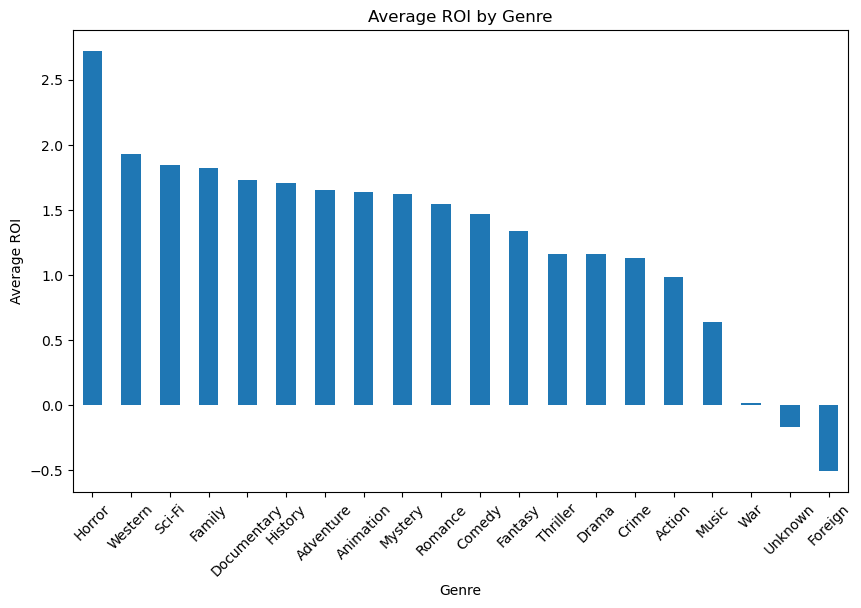

In [6]:
plt.figure(figsize=(10,6))
genre_roi_median.plot(kind='bar')

plt.title("Average ROI by Genre")
plt.xlabel("Genre")
plt.ylabel("Average ROI")
plt.xticks(rotation=45)
plt.show()

### Interpretation — Genre vs. ROI

| Metric | Top Genre | ROI Value |
|--------|-----------|----------|
| Mean ROI | Horror | ~103× |
| Median ROI | Horror | ~2.7× |

**Horror dominates ROI by a wide margin**, both in mean and median terms. The extreme mean (≈103×) is driven by micro-budget breakout hits (further examined in Analysis 6), while the median (~2.7×) confirms this is a *systemic* advantage, not merely an outlier effect.

**Documentary** ranks second in mean ROI (~21.5×), benefiting from minimal production costs and occasionally viral cultural moments. **Western** and **Sci-Fi** lead in median ROI (~1.9× and ~1.8×), suggesting consistent profitability for those genres.

**Thriller** and **Action** — despite being high-volume genres — show comparatively modest median ROIs, likely because their larger average budgets reduce proportional returns.

> **Key takeaway:** Genre is a significant predictor of ROI. Horror offers the most capital-efficient returns; high-budget spectacle genres (Action, Adventure) trade ROI efficiency for absolute revenue scale.

---

## Analysis-2: Budget Vs. Revenue

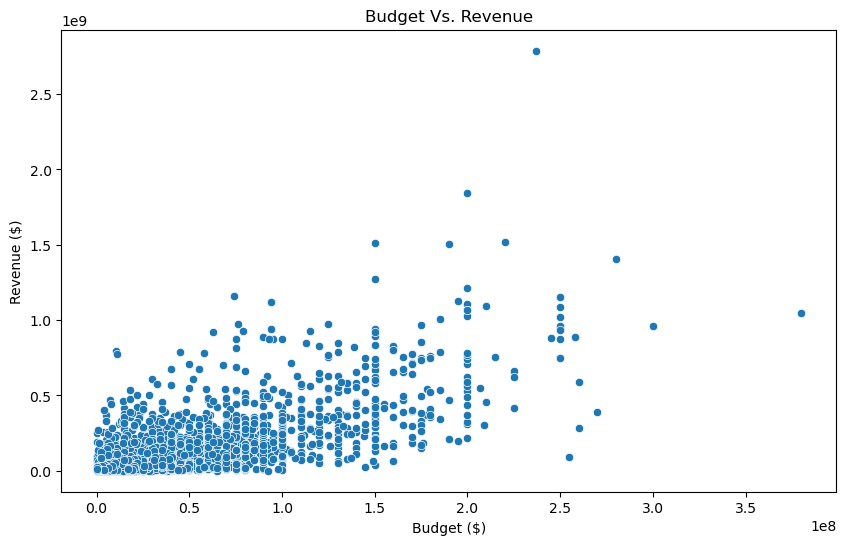

In [7]:
# Budget Vs. Revenue. Do bigger budgets lead to higher revenue?
plt.figure(figsize=(10,6))
sns.scatterplot(x='Budget ($)', y='Revenue ($)', data=df)

plt.title('Budget Vs. Revenue')
plt.xlabel('Budget ($)')
plt.ylabel('Revenue ($)')
plt.show()


## Correlation between Budget and Revenue

In [8]:
# Correlation. How correlated budget and revenue are.
corr = df['Budget ($)'].corr(df['Revenue ($)'])
print("Correlation:", corr)

Correlation: 0.7046254051397385


### Interpretation — Budget vs. Revenue

**Pearson correlation: r = 0.70** — a strong positive relationship between production budget and revenue.

The scatter plot confirms a clear upward trend: studios that invest more generally earn more. However, the wide dispersion at higher budget values indicates that large budgets *do not guarantee* proportionally large returns — several high-budget films significantly underperformed.

Notable observations:
- The cluster of films with budgets under $50M shows high variance in revenue, reflecting the unpredictability of lower-budget releases.
- Films exceeding $150M in budget tend to cluster toward higher revenue bands, consistent with studio blockbuster strategy.

> **Key takeaway:** Budget is a meaningful revenue driver, but it explains only ~49% of variance (r² ≈ 0.49). Marketing spend, release timing, franchise equity, and genre each contribute independent variance that budget alone cannot capture.

---

## Analysis-3: Vote Average Vs. Revenue

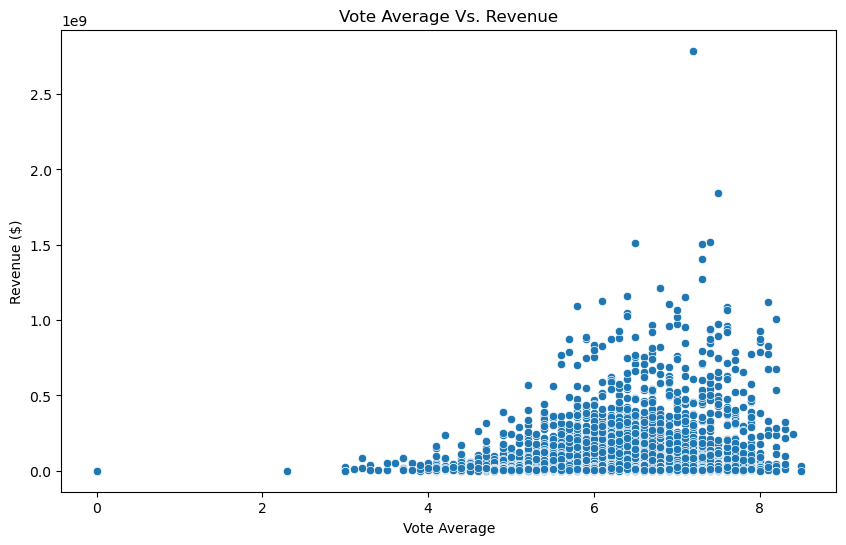

Correlation: 0.18889303445096853


In [9]:
# Vote_average Vs. Revenue
plt.figure(figsize=(10,6))
sns.scatterplot(x='Vote Average', y='Revenue ($)', data=df);

plt.ylabel('Revenue ($)')
plt.xlabel('Vote Average')
plt.title('Vote Average Vs. Revenue')
plt.show()

# Correlation Analysis
corr2 = df['Vote Average'].corr(df['Revenue ($)'])
print("Correlation:", corr2)

### Interpretation — Vote Average vs. Revenue

**Pearson correlation: r = 0.19** — a very weak positive relationship between audience rating and revenue.

The scatter plot reveals no clear linear trend: highly rated films appear at all revenue levels, and several commercially dominant blockbusters carry only moderate vote averages. This is a critical insight — **critical and audience reception is not a reliable predictor of box office performance**.

Possible explanations:
- Franchise recognition, IP loyalty, and marketing budgets drive ticket sales independently of quality.
- Films with polarizing or niche appeal can receive high ratings from smaller but devoted audiences while generating modest revenue.
- Timing, competition, and distribution scale influence revenue more than content quality metrics.

> **Key takeaway:** A high vote average does not translate to high revenue. Studios optimizing for box office returns should prioritize brand, franchise, and market positioning over critical reception alone.

---

## Analysis-4: Release Year Vs. Revenue

In [10]:
# ReleaseYear Vs. Revenue
year_revenue = df.groupby('Release Year')['Revenue ($)'].mean()

print(year_revenue)

Release Year
1916    8.394751e+06
1925    2.200000e+07
1927    6.504220e+05
1929    4.358000e+06
1930    8.000000e+06
            ...     
2012    1.735361e+08
2013    1.542375e+08
2014    1.781277e+08
2015    1.857632e+08
2016    2.007115e+08
Name: Revenue ($), Length: 88, dtype: float64


In [11]:
# Set display format to normal floats
pd.options.display.float_format = '{:.2f}'.format

year_revenue2 = df.groupby('Release Year')['Revenue ($)'].mean()
print(year_revenue2)

Release Year
1916     8394751.00
1925    22000000.00
1927      650422.00
1929     4358000.00
1930     8000000.00
           ...     
2012   173536078.14
2013   154237532.74
2014   178127674.61
2015   185763156.55
2016   200711484.07
Name: Revenue ($), Length: 88, dtype: float64


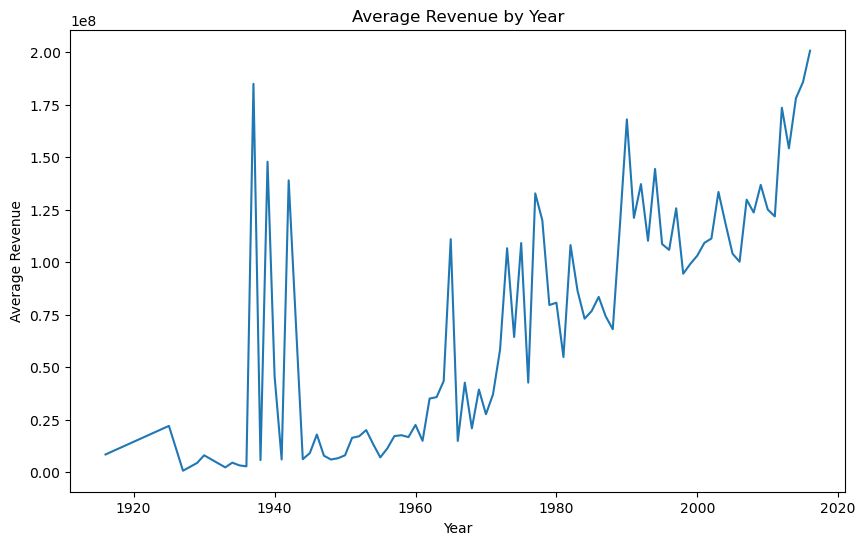

In [12]:
# Visualization
plt.figure(figsize=(10,6))
year_revenue2.plot()

plt.title("Average Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Average Revenue")
plt.show()

### Interpretation — Release Year vs. Average Revenue

Average revenue per film shows a pronounced upward trajectory, particularly from the **1990s onward**. The line chart reveals three broad phases:

| Era | Trend | Context |
|-----|-------|--------|
| Pre-1970s | Low & flat | Limited global distribution, smaller market |
| 1970s–1990s | Gradual rise | Multiplex expansion, VHS ancillary revenue |
| 2000s–2016 | Steep growth | Franchise era, China/emerging markets, digital distribution |

The most recent years in the dataset (2012–2016) show average revenues in the **\$150M–\$200M** range, reflecting the dominance of large-scale franchise productions in the modern era.

> **Key takeaway:** Revenue benchmarks have shifted dramatically over decades. Historical comparisons must account for inflation and structural market changes. Modern films operate in a fundamentally higher-ceiling, higher-floor environment.

---

## Analysis-5: Top by Revenue

In [13]:
# Top by Revenue 
top_revenue = df.sort_values(by='Revenue ($)', ascending=False).head(10)

print(top_revenue[['Title', 'Revenue ($)', 'Budget ($)']])

                           Title  Revenue ($)  Budget ($)
1087                      Avatar   2787965087   237000000
2472                     Titanic   1845034188   200000000
497                 The Avengers   1519557910   220000000
106               Jurassic World   1513528810   150000000
108                    Furious 7   1506249360   190000000
104      Avengers: Age of Ultron   1405403694   280000000
333                       Frozen   1274219009   150000000
337                   Iron Man 3   1215439994   200000000
161                      Minions   1156730962    74000000
67    Captain America: Civil War   1153304495   250000000


### Interpretation — Top 10 Films by Revenue

| Rank | Title | Revenue | Budget |
|------|-------|---------|--------|
| 1 | Avatar | $2.79B | $237M |
| 2 | Titanic | $1.85B | $200M |
| 3 | The Avengers | $1.52B | $220M |
| 4 | Jurassic World | $1.51B | $150M |
| 5 | Furious 7 | $1.51B | $190M |

Every film in the top-10 carries a production budget of **\$74M or more**, and all are either franchise sequels, event films, or genre-defining spectacles. The data reinforces that **absolute revenue leadership belongs to high-investment, high-visibility productions**.

Notably, *Minions* ($74M budget → $1.16B revenue) stands out as the most capital-efficient film in this group, leveraging a proven IP to achieve outsized returns relative to its budget.

> **Key takeaway:** Top-grossing films are not simply well-made — they are products of large-scale franchise ecosystems, major studio distribution, and global marketing campaigns. Revenue leadership and ROI leadership are *distinct* performance dimensions (see Analysis 6).

---

## Analysis-6: Top by ROI

In [14]:
# Top by ROI
top_roi = df.sort_values(by='Return on Investment (ROI)', ascending=False).head(10)

print(top_roi[['Title', 'Return on Investment (ROI)', 'Budget ($)']])

                             Title  Return on Investment (ROI)  Budget ($)
1292           Paranormal Activity                    12889.39       15000
2357       The Blair Witch Project                     4132.33       60000
3035                    Eraserhead                      699.00       10000
3069                Pink Flamingos                      499.00       12000
1687                 Super Size Me                      438.62       65000
186                    The Gallows                      425.64      100000
1728                    Open Water                      419.52      130000
3056  The Texas Chain Saw Massacre                      362.05       85000
3189                         Bambi                      310.71      858000
3093              The Stewardesses                      269.00      100000


### Interpretation — Top 10 Films by ROI

| Rank | Title | ROI | Budget |
|------|-------|-----|--------|
| 1 | Paranormal Activity | ~12,889× | $15,000 |
| 2 | The Blair Witch Project | ~4,132× | $60,000 |
| 3 | Eraserhead | ~699× | $10,000 |
| 4 | Pink Flamingos | ~499× | $12,000 |
| 5 | Super Size Me | ~439× | $65,000 |

The highest-ROI films are almost exclusively **micro-budget horror and documentary productions** — a stark contrast to Analysis 5. *Paranormal Activity's* ≈12,889× ROI on a **\$15,000 budget** represents one of the most extreme outliers in cinematic financial history.

This pattern is structurally logical: with near-zero downside risk, even a modest theatrical release produces extraordinary multiples. The genre skew (horror, documentary, exploitation) reflects the narrative and aesthetic conventions that allow ultra-low-budget filmmaking to connect with mass audiences through novelty or cultural provocation.

> **Key takeaway:** ROI and revenue are *inversely correlated at the extremes*. The most capital-efficient investments in film are micro-budget horror and documentary productions — not the blockbusters that dominate headlines. Investment strategy should clearly distinguish the goal: absolute revenue vs. capital efficiency.

---

## Analysis-7: Count the Number of Movies Per Genre

In [15]:
# Count movies per genre
genre_count = df['Genres'].value_counts()
print(genre_count)

Genres
Drama          741
Comedy         630
Action         588
Adventure      287
Horror         196
Crime          141
Thriller       116
Animation       99
Fantasy         92
Sci-Fi          79
Romance         69
Family          38
Documentary     29
Mystery         26
Western         22
Music           20
War             18
History         18
Foreign          1
Unknown          1
Name: count, dtype: int64


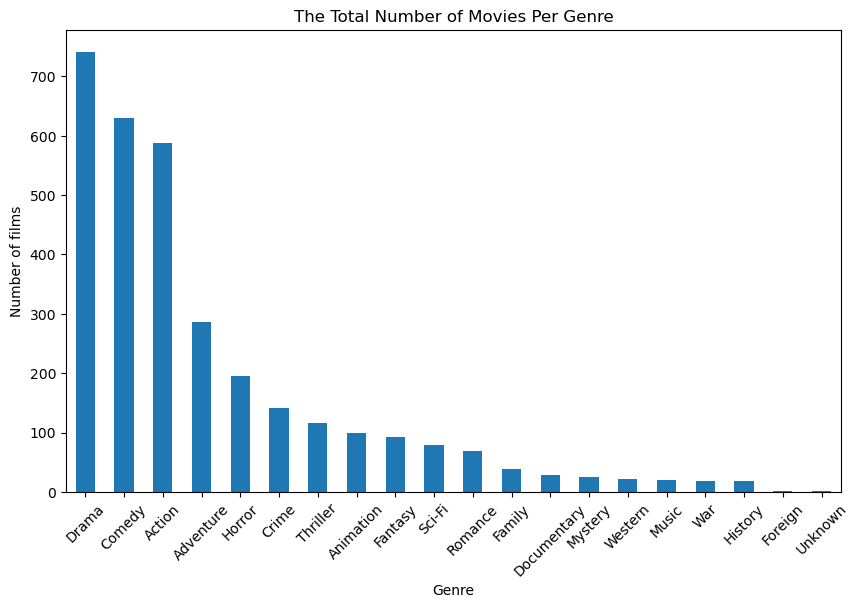

In [16]:
plt.figure(figsize=(10,6))
genre_count.plot(kind='bar')

plt.title("The Total Number of Movies Per Genre")
plt.xlabel("Genre")
plt.ylabel("Number of films")
plt.xticks(rotation=45)
plt.show()

### Interpretation — Movie Count by Genre

**Drama** (741), **Comedy** (630), and **Action** (588) are the three most prolific genres in the dataset, collectively accounting for over **50%** of all films. This reflects the dominant production strategy of major studios and independent filmmakers alike.

Cross-referencing with Analysis 1 reveals a critical **production vs. profitability mismatch**:

| Genre | Production Volume | Median ROI Rank |
|-------|------------------|-----------------|
| Drama | Highest (741) | Mid-tier |
| Comedy | 2nd (630) | Lower-mid |
| Horror | Lower-mid (196) | **1st** |

Horror — the most ROI-efficient genre — is produced at less than **27%** the volume of Drama, suggesting a systematic market underexploitation. Documentary (29 films) similarly punches above its weight in mean ROI despite minimal production volume.

> **Key takeaway:** The most-produced genres are not the most profitable by ROI. Production volume reflects historical industry habit and talent availability more than financial optimization. A genre-aware production strategy could improve portfolio ROI by increasing the proportion of low-budget Horror and Documentary productions.

---

## Summary & Conclusions

---

This exploratory analysis examined seven dimensions of movie success using TMDB data. The findings are summarized below:

| Analysis | Key Finding |
|----------|-------------|
| Genre vs. ROI | Horror is the most capital-efficient genre; mean ROI ≈103×, median ROI ≈2.7× |
| Budget vs. Revenue | Strong positive correlation (r = 0.70); budget explains ~49% of revenue variance |
| Vote Average vs. Revenue | Very weak correlation (r = 0.19); quality does not reliably predict box office |
| Release Year vs. Revenue | Revenue has grown substantially since the 1990s; modern films operate in a higher-ceiling market |
| Top by Revenue | All top-grossing films are high-budget franchise/event productions ($74M–$280M budgets) |
| Top by ROI | Highest ROI films are micro-budget horror/documentary productions (budgets under $100K) |
| Genre Distribution | Drama, Comedy, and Action dominate production volume but not ROI efficiency |

### Strategic Implications

1. **For investors seeking capital efficiency:** Micro-budget Horror and Documentary films offer the highest risk-adjusted returns, as evidenced by both median ROI rankings and extreme ROI outliers.
2. **For studios targeting absolute revenue:** High-budget franchise productions in Action, Adventure, and Animation remain the reliable path to box-office leadership.
3. **Budget allocation:** A 0.70 correlation between budget and revenue confirms that investment scale matters — but diminishing returns and high-budget failures suggest optimal allocation lies in the $20M–$100M range for balanced risk/reward.
4. **Quality vs. commercial success:** Audience ratings are a poor standalone predictor of revenue. Marketing, timing, franchise equity, and genre selection are more actionable levers.

---
*Analysis conducted on TMDB Movies dataset. All monetary figures are nominal USD (not inflation-adjusted).*